In [1]:
#Metadados
__author__ = "Luidy"
__version__ = "2.0.0"
__status__ = "fabricando 2º prototipo"

#Bibliotecas Padrão
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Algoritmos de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Ferramentas de Treino e Validação
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.inspection import permutation_importance 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, 
    make_scorer, 
    ConfusionMatrixDisplay, 
    recall_score,           
    accuracy_score,          
    classification_report,
    roc_curve,                
    roc_auc_score,            
    precision_recall_curve,   
    average_precision_score   
)

# 5. Configurações Visuais
sns.set(style="whitegrid")
import warnings
warnings.filterwarnings('ignore') 

In [2]:
#criando funções basicas para melhor vizualização e impressão
def linha(tamanho = 60):
    print("_"*tamanho)
def dimensoes(dataframe,opcao):
    match opcao:
        case 0:
            print(f"Dimensões atuais do dataframe:{dataframe.shape}")
            linha()
        case 1:
            print(f"Dimensões atuais do dataframe:{dataframe.shape}")
            linha()
            display(dataframe.head())
        case _:
            print("Opção invalida. Sintaxe (dataframe,opção[0 ou 1])")

In [3]:
#criando função de carregamentode dataset
def carregar_dataset(caminho):
    linha(90)
    print("INICIANDO CARREGAMENTO DE DATASET")
    print(f"Buscando arquivo {caminho}...")

    #indicando sucesso da execução da função
    try:
        print("Arquivo encontrado! carregando dataset...")
        #df_sujo = dataframe sujo
        df_sujo = pd.read_csv(caminho, low_memory=False)
        print("Arquivo bruto carregado")
        dimensoes(df_sujo,1)
        return(df_sujo)
    # exceção para caso não seja encontrado o arquivo indicado
    except FileNotFoundError:
        print(f"Arquivo {caminho} não encontrade, certifique-se que o nome esta correto e se o arquivo esta no endereço informado")
        return(None)
    #exceção para qualquer outro tipo de erro, porem ela indica o tipo de erro ocorrido
    except Exception as error:
        print(f"Erro desconhecido: {error}")
        return(None)
    

In [4]:
#criando funções para tratamento de dados
#Filtagem de Colunas
def filtrar_colunas(dataframe):
    #definindo quais colunas serão usadas para treinamento e suas traduções
    mapa_colunas={
        'label': 'Target',           
        'C-424144002': 'Idade', 
        'C-263495000': 'Genero', 
        'C-72166-2': 'Fumo',
        'C-9279-1': 'Freq_Respiratoria', 
        'C-8867-4': 'Freq_Cardiaca', 
        'C-8480-6': 'Pressao_Sistolica', 
        'C-8462-4': 'Pressao_Diastolica',
        'C-267036007': 'Falta_Ar', 
        'C-66857006': 'Tosse_Sangue', 
        'C-39156-5': 'IMC', 
        'C-2708-6': 'Sat_Oxigenio', 
        'C-49727002': 'Tosse', 
        'C-84229001': 'Fadiga', 
        'C-7200002': 'Alcoolismo', 
        'C-56018004': 'Chiado'
    }

    print("Filtrando Colunas...")
    linha()
    
    colunas_existentes = []
    for c in mapa_colunas.keys():
        if c in dataframe.columns:
            colunas_existentes.append(c)
   
    df = dataframe[colunas_existentes].rename(columns=mapa_colunas)

    dimensoes(df,0)
    return(df)
    
#criando função para tratamento dos dados propriamente dito
def tratar_dados(dataframe):
    #tratando valores booleanos 
    print("tratando valores booleanos...")
    linha()
    booleanos = [
        'Falta_Ar',
        'Tosse_Sangue',
        'Tosse',
        'Fadiga',
        'Alcoolismo',
        'Chiado'
    ]
    for c in booleanos:
        if c in dataframe.columns:
            dataframe[c]= dataframe[c].fillna(0).astype(str).replace({
                'True':1,
                "1":1,
                "1.0":1,
                'False':0,
                '0':0,
                "0.0":0
            })
            dataframe[c]=pd.to_numeric(dataframe[c], errors='coerce').fillna(0).astype(int)
    #tratando valores categoricos binarios
    print("tratando valores categoricos binarios...")
    linha()
    categoricos = [
        'Freq_Respiratoria',
        'Freq_Cardiaca',
        'Pressao_Sistolica',
        'Pressao_Diastolica']
    for c in categoricos:
        if c in dataframe.columns:
            dataframe[c]=dataframe[c].fillna('normal')

    #tratando valores booleanod não binarios
    print("tratando valores booleanod não binarios...")
    linha()
    if "Fumo" in dataframe.columns:
        dataframe["Fumo"]= dataframe["Fumo"].fillna("fumante_ativo").replace({
            "never":"não_fumante",
            "former":"ex_fumante"
        })
    if "Idade" in dataframe.columns:
        dataframe['Idade'] = dataframe['Idade'].replace({
            "50t70":"50_a_70_anos",
            "gt70":"Mais_de_70",
            "30t50":"30_a_50_anos"
        })
    
    #excluindo duplicatas
    print("Verificando duplicatas...")
    duplicatas = dataframe.duplicated().sum()

    print(f'{duplicatas} duplicatas encontradas')
    print("Apagando duplicatas...")
    linha()

    dataframe = dataframe.drop_duplicates()
    
    #criando dummies
    print("Criando dummies...")
    linha()
    dataframe = pd.get_dummies(dataframe,drop_first=True)

    dataframe = dataframe.replace({
        True:1,
        False:0
    })

    print("Dados tratados com sucesso!")
    linha()
    
    for i in dataframe.columns:
        print(f'🔸{i}:{dataframe[i].unique()}')

    dimensoes(dataframe,1)

    return(dataframe)

In [5]:
#criando funções para o treinamento do modelo
def preparar_dados_treino(dataframe, classe):
    #exceção para o caso do dataframe ser enviado incorretamente
    if dataframe is None:
        print("O dataframe não foi enviado, corrija e tente novamente")
        linha()
    else:
        print("Preparando o ambiente para treino dos modelos")
        #definindo dependencias e independencias
        x = dataframe.drop(columns=classe)
        y = dataframe[classe]
        
        #definindo configurações de treino
        x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.3, stratify=y, random_state=42)

        scaler = StandardScaler()

        x_treino_scaled = scaler.fit_transform(x_treino)
        x_treino = pd.DataFrame(x_treino_scaled, columns=x.columns, index=x_treino.index)

        x_teste_scaled = scaler.transform(x_teste)
        x_teste = pd.DataFrame(x_teste_scaled, columns=x.columns, index=x_teste.index)

        print(f"   -> Total: {dataframe.shape}")
        print(f"   -> Treino: {x_treino.shape}")
        print(f"   -> Teste:  {x_teste.shape}")
        linha()
        
        algoritmos = {
            "Regressão Logística": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
            "Árvore de Decisão":   DecisionTreeClassifier(class_weight='balanced', random_state=42),
            "Random Forest":       RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
            "SVM (Support Vector)": SVC(probability=True, class_weight='balanced', random_state=42),
            "Gradient Boosting":   GradientBoostingClassifier(random_state=42)
        }

        return x_treino, x_teste, y_treino, y_teste, algoritmos

#criando a função de comparação de efetividade de algoritmos para o modelo
def comparacao_algoritmos(x_treino, x_teste, y_treino, y_teste, algoritmos):
    print("Iniciando comparação de efetividade de algoritmos...")
    print("Esse teste é feito com base em dois critérios:")
    print("Critério 1: Recall - quantos pacientes doentes (câncer inicial) são acertados")
    print("Critério 2: Especificidade - em caso de empate, será escolhido o que acertar mais saudáveis")
    print("Margem de erro para empate: 1%")
    linha()

    #definindo paramentros de avaliação
    scorer = {
        'recall': "recall",
        "especificidade" : make_scorer(recall_score, pos_label=0)
    }

    #definindo em quantas pastas serão separados os dados na validação cruzada
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    resultados = []

    print(f"{'MODELO':<25} | {'RECALL':^10} | {'ESPECIF.':^10} | {'DESVIO REC.':^14} | {'DESVIO ESPEC.':^15}")
    linha(85)
    s
    for nome, modelo in algoritmos.items():
        scores = cross_validate(modelo, x_treino, y_treino, cv=kfold, scoring=scorer)
    
        media_recall = scores['test_recall'].mean()
        desvio_recall = scores['test_recall'].std()
    
        media_espec = scores["test_especificidade"].mean()
        desvio_espec = scores["test_especificidade"].std()
    
        resultados.append({
            'Modelo': nome,
            'Recall': media_recall,
            'Min.Recall': media_recall - desvio_recall,
            'Especificidade': media_espec,
            'Min.Especificidade': media_espec - desvio_espec,
            'Objeto': modelo
        })
    
        str_desvio_rec = f"[+/-]{desvio_recall:.2%}"
        str_desvio_espec = f"[+/-]{desvio_espec:.2%}"
    
        print(f"{nome:<25} | {media_recall:^10.2%} | {media_espec:^10.2%} | {str_desvio_rec:^14} | {str_desvio_espec:^15}")

    podio = pd.DataFrame(resultados).sort_values(by='Min.Recall', ascending=False).reset_index(drop=True)

    primeiro = podio.iloc[0]
    segundo = podio.iloc[1]

    diferenca = primeiro["Min.Recall"] - segundo["Min.Recall"]
    margem_empate = 0.01

    melhor_modelo = None
    nome_vencedor = ""

    if diferenca <= margem_empate:
        print(f"Empate tecnico entre {primeiro['Modelo']} e {segundo['Modelo']}, com diferença de {diferenca:.2%}")
        print("Usando critério de desempate...")

        if primeiro["Min.Especificidade"] >= segundo["Min.Especificidade"]:
            print(f"O {primeiro['Modelo']} venceu o desempate!")
            linha()
            melhor_modelo = primeiro['Objeto']
            nome_vencedor = primeiro['Modelo']
        else:
            print(f"O {segundo['Modelo']} venceu o desempate! Virada!")
            linha()
            melhor_modelo = segundo['Objeto']
            nome_vencedor = segundo['Modelo']
    else:
        print(f"Vitoria do algoritmo: {primeiro['Modelo']} - venceu com folga no Recall.")
        linha()
        melhor_modelo = primeiro['Objeto']
        nome_vencedor = primeiro['Modelo']
    
    print(f"Vencedor em desempenho: {nome_vencedor.upper()}")

    melhor_modelo.fit(x_treino, y_treino)

    return melhor_modelo, nome_vencedor

# --- Funções Modulares ---

def gerar_relatorio_metricas(y_teste, predicao):
    print("Relatório de Classificação:")
    print(classification_report(y_teste, predicao))
    linha()

def gerar_matriz_confusao(y_teste, predicao, nome_modelo):
    print("Gerando Matriz de Confusão...")
    fig, ax = plt.subplots(figsize=(8, 5))
    ConfusionMatrixDisplay.from_predictions(y_teste, predicao, cmap='Blues', ax=ax)
    ax.set_title(f"Matriz de Confusão: {nome_modelo}")
    plt.show()

def gerar_grafico_importancia(modelo, nome_modelo, x_teste, y_teste):
    print("\n🔍 Analisando Fatores de Risco (O que o modelo considera importante?)...")
    
    importancias_brutas = None
    
    if hasattr(modelo, 'feature_importances_'):
        importancias_brutas = modelo.feature_importances_
    elif hasattr(modelo, 'coef_'):
        importancias_brutas = abs(modelo.coef_[0]) 

    # 1. Gráfico de Importância Bruta
    if importancias_brutas is not None:
        df_imp = pd.DataFrame({
            'Feature': x_teste.columns,
            'Importancia': importancias_brutas
        }).sort_values(by='Importancia', ascending=False)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importancia', y='Feature', data=df_imp.head(10), palette='viridis')
        plt.title(f"Top 10 Fatores de Decisão (Coeficientes Brutos) - {nome_modelo}")
        plt.xlabel("Peso da Influência")
        plt.ylabel("Variável Clínica")
        plt.show()
    else:
        print(f"⚠️ AVISO: O modelo {nome_modelo} não permite visualizar a importância direta das features.")
        print("   -> Isso é normal para SVM com kernel RBF (Caixa Preta Matemática).")

    # 2. Permutation Importance no conjunto de Teste
    print("\n🔍 Investigando Robustez (Permutation Importance no Teste)...")
    resultado_pi = permutation_importance(modelo, x_teste, y_teste, n_repeats=10, random_state=42, n_jobs=-1)
    
    df_pi = pd.DataFrame({
        'Feature': x_teste.columns,
        'Importancia_Permutacao': resultado_pi.importances_mean,
        'Desvio': resultado_pi.importances_std
    }).sort_values(by='Importancia_Permutacao', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importancia_Permutacao', y='Feature', data=df_pi.head(10), palette='magma')
    plt.title(f"Permutation Importance (Teste) - {nome_modelo}")
    plt.xlabel("Queda no Desempenho (Importância Real)")
    plt.ylabel("Variável Clínica")
    plt.show()s

def avaliar_curvas(modelo, nome_modelo, x_teste, y_teste):
    """Gera AUC-ROC e curva Precision-Recall para o modelo vencedor."""
    if not hasattr(modelo, "predict_proba"):
        print(f"⚠️ AVISO: {nome_modelo} não expõe predict_proba; "
              "não é possível calcular AUC-ROC/PR para este modelo.")
        return

    proba_positiva = modelo.predict_proba(x_teste)[:, 1]

    # --- AUC-ROC ---
    fpr, tpr, _ = roc_curve(y_teste, proba_positiva)
    auc_roc = roc_auc_score(y_teste, proba_positiva)

    # --- Curva Precision-Recall ---
    precisao, recall, _ = precision_recall_curve(y_teste, proba_positiva)
    auc_pr = average_precision_score(y_teste, proba_positiva)

    prevalencia = y_teste.mean()

    print(f"AUC-ROC ({nome_modelo}): {auc_roc:.3f}")
    print(f"AUC-PR / Average Precision ({nome_modelo}): {auc_pr:.3f}")
    print(f"Prevalência da classe positiva no teste: {prevalencia:.3f} "
          f"(linha de base de um classificador aleatório na curva PR)")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(fpr, tpr, label=f"AUC = {auc_roc:.3f}", color="steelblue")
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Classificador aleatório")
    axes[0].set_xlabel("Taxa de Falsos Positivos (1 - Especificidade)")
    axes[0].set_ylabel("Taxa de Verdadeiros Positivos (Recall)")
    axes[0].set_title(f"Curva ROC — {nome_modelo}")
    axes[0].legend(loc="lower right")

    axes[1].plot(recall, precisao, label=f"AP = {auc_pr:.3f}", color="darkorange")
    axes[1].axhline(y=prevalencia, linestyle="--", color="gray", label=f"Linha de base (prevalência = {prevalencia:.2f})")
    axes[1].set_xlabel("Recall (Sensibilidade)")
    axes[1].set_ylabel("Precisão (VPP)")
    axes[1].set_title(f"Curva Precision-Recall — {nome_modelo}")
    axes[1].legend(loc="lower left")

    plt.tight_layout()
    plt.show()

    return {
        "auc_roc": auc_roc,
        "auc_pr": auc_pr,
        "prevalencia": prevalencia,
    }

__________________________________________________________________________________________
INICIANDO CARREGAMENTO DE DATASET
Buscando arquivo dataset_completo_v2.csv...
Arquivo encontrado! carregando dataset...
Arquivo bruto carregado
Dimensões atuais do dataframe:(26295, 788)
____________________________________________________________


,ptnum,label,scc,C-44465007,C-392091000,C-248595008,C-6246-3,C-197927001,C-234262008,C-389221,...,C-287185009,C-313572,C-406602003,C-427089005,C-444260001,C-707418001,C-86964003,C-103746007,C-1191222,C-13995008
0,p15865,1,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,p27452,1,145,True,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,p12382,1,133,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,p21814,1,132,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,p2902,1,127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Filtrando Colunas...
____________________________________________________________
Dimensões atuais do dataframe:(26295, 16)
____________________________________________________________
____________________________________________________________
Auditoria de Nulos (IMC, Sat_Oxigenio, Genero) antes do tratamento:
IMC                13
Sat_Oxigenio    16806
Genero              0
dtype: int64
____________________________________________________________
tratando valores booleanos...
____________________________________________________________
tratando valores categoricos binarios...
____________________________________________________________
tratando valores booleanod não binarios...
____________________________________________________________
Verificando duplicatas...
25711 duplicatas encontradas
Apagando duplicatas...
____________________________________________________________
Criando dummies...
____________________________________________________________
Dados tratados com sucesso!
__

,Target,Falta_Ar,Tosse_Sangue,Tosse,Fadiga,Alcoolismo,Chiado,Idade_50_a_70_anos,Idade_Mais_de_70,Genero_m,Fumo_fumante_ativo,Fumo_não_fumante,Freq_Respiratoria_normal,Freq_Cardiaca_normal,Pressao_Sistolica_normal,Pressao_Diastolica_normal,IMC_normal
0,1,0,0,0,0,0,0,0,1,1,0,0,1,1,1,1,0
1,1,0,0,0,0,0,0,0,1,1,0,1,1,1,1,1,0
4,1,0,0,0,0,0,0,1,0,1,0,1,1,1,0,0,0
6,1,0,0,0,0,0,0,1,0,1,0,1,1,1,1,1,0
7,1,0,0,0,0,0,0,1,0,1,0,0,1,1,1,1,0


Preparando o ambiente para treino dos modelos
   -> Total: (584, 17)
   -> Treino: (408, 16)
   -> Teste:  (176, 16)
____________________________________________________________
Iniciando comparação de efetividade de algoritmos...
Esse teste é feito com base em dois critérios:
Critério 1: Recall - quantos pacientes doentes (câncer inicial) são acertados
Critério 2: Especificidade - em caso de empate, será escolhido o que acertar mais saudáveis
Margem de erro para empate: 1%
____________________________________________________________
MODELO                    |   RECALL   |  ESPECIF.  |  DESVIO REC.   |  DESVIO ESPEC. 
_____________________________________________________________________________________
Regressão Logística       |   82.00%   |   82.97%   |  [+/-]13.27%   |   [+/-]4.21%   
Árvore de Decisão         |   52.00%   |   88.28%   |   [+/-]4.00%   |   [+/-]3.21%   
Random Forest             |   50.00%   |   92.18%   |   [+/-]6.32%   |   [+/-]2.41%   
SVM (Support Vector)      

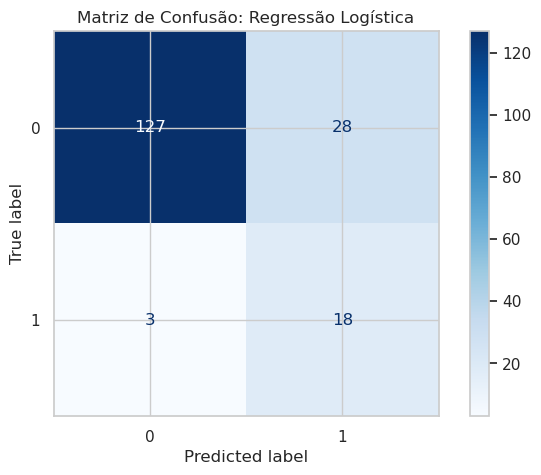


🔍 Analisando Fatores de Risco (O que o modelo considera importante?)...


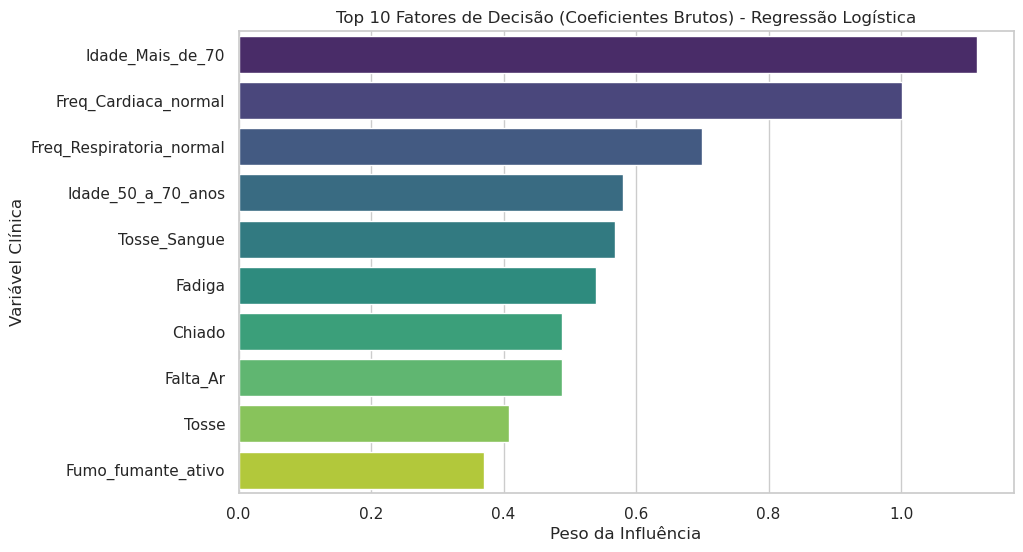


🔍 Investigando Robustez (Permutation Importance no Teste)...


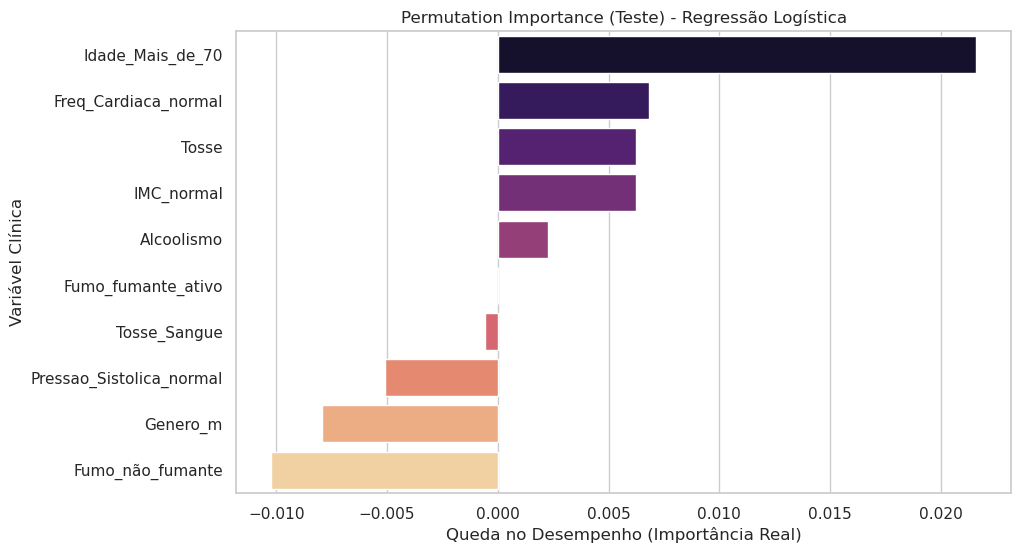

AUC-ROC (Regressão Logística): 0.919
AUC-PR / Average Precision (Regressão Logística): 0.636
Prevalência da classe positiva no teste: 0.119 (linha de base de um classificador aleatório na curva PR)


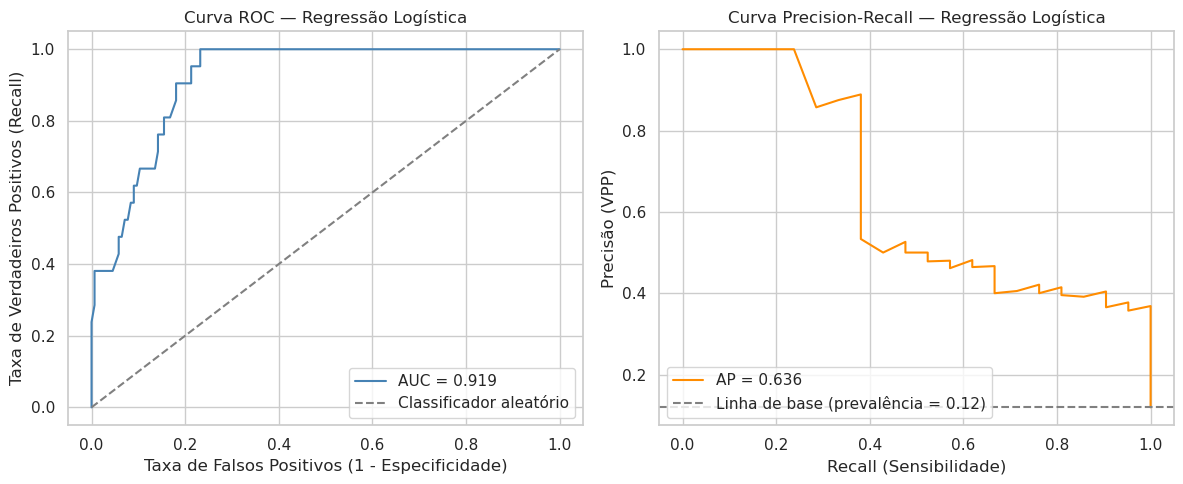

In [6]:
df = carregar_dataset("dataset_completo_v2.csv") 

df = filtrar_colunas(df)

# 1. Auditoria de dados (antes do tratamento)
linha()
print("Auditoria de Nulos (IMC, Sat_Oxigenio, Genero) antes do tratamento:")
print(df[['IMC','Sat_Oxigenio','Genero']].isna().sum())
linha()

df = tratar_dados(df)

# Nomenclatura corrigida para 'algoritmos'
x_treino, x_teste, y_treino, y_teste, algoritmos = preparar_dados_treino(df, "Target")

# Nomenclatura corrigida para 'comparacao_algoritmos'
modelo, nome_modelo = comparacao_algoritmos(x_treino, x_teste, y_treino, y_teste, algoritmos)

# Geração das predições para as novas funções modulares
predicao = modelo.predict(x_teste)

# Chamadas das funções gráficas e de métricas separadas
gerar_relatorio_metricas(y_teste, predicao)
gerar_matriz_confusao(y_teste, predicao, nome_modelo)

# Atualizado para receber y_teste (necessário para o permutation importance)
gerar_grafico_importancia(modelo, nome_modelo, x_teste, y_teste)

# Nova função para AUC-ROC e Precision-Recall
resultados_curvas = avaliar_curvas(modelo, nome_modelo, x_teste, y_teste)